In [3]:
from utils import utils_ml
import numpy as np 

In [4]:
features_memmap = np.load('features_filtered_T11T12NoBG.npy', mmap_mode='r')


# features_memmap = np.load('data/features_filtered.npy', mmap_mode='r')
old_label_arr = np.array([np.tile(i,10000) for i in np.arange(0,35)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}

# new_label_arr = convert_labels(old_label_arr, class_to_poles)


In [7]:
class Ensemble(object):
    
    def __init__(self, esize=10, iterations=1000, lr=0.1, random_strength=0, border_count=128, depth=6, seed=100):
        
        
        self.seed = seed
        self.esize=esize
        self.depth = depth
        self.iterations=iterations
        self.lr=lr
        self.random_strength = random_strength
        self.border_count = border_count
        self.ensemble = []
        for e in range(self.esize):
            model = CatBoostClassifier(iterations=self.iterations,
                           depth=self.depth,
                           learning_rate=self.lr,
                           border_count=self.border_count,
                           random_strength=self.random_strength,
                           loss_function='MultiClass',
                           verbose=100,
                           bootstrap_type='No',
                           posterior_sampling=True,
                           random_seed=self.seed+e,
                           early_stopping_rounds=10)
            self.ensemble.append(model)
        
    def fit(self, data, eval_set = None):
        
        for m in self.ensemble:
            m.fit(data, eval_set=eval_set)
            print("best iter ", m.get_best_iteration())
            print("best score ", m.get_best_score())
            
    
    def predict(self,x):
        probs = []
        
        for m in self.ensemble:
            prob = m.predict_proba(x)
            probs.append(prob)
        probs = np.stack(probs)
        return probs
    


def kl_divergence(probs1, probs2, epsilon=1e-10):
    return np.sum(probs1 * (np.log(probs1 + epsilon) - np.log(probs2 + epsilon)), axis=1)

def entropy_of_expected(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    log_probs = -np.log(mean_probs + epsilon)
    return np.sum(mean_probs * log_probs, axis=1)

def expected_entropy(probs, epsilon=1e-10):
    log_probs = -np.log(probs + epsilon)

    return np.mean(np.sum(probs * log_probs, axis=2), axis=0)

def mutual_information(probs, epsilon):
    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    return eoe - exe

def ensemble_uncertainties(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    conf = np.max(mean_probs, axis=1)

    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    mutual_info = eoe - exe


    uncertainty = {'confidence': conf,
                   'entropy_of_expected': eoe,        # total_uncertainty !
                   'expected_entropy': exe,           # data_uncertainty !
                   'mutual_information': mutual_info, # Knowledge Uncertainty!
                  }

    return uncertainty



In [29]:
X_train, X_test, y_train, y_test = train_test_split(features_memmap[::10], old_label_arr[::10], test_size=0.1, random_state=42)
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_test, y_test)

ens = Ensemble(esize=5, iterations=500, lr=0.1, depth=6, seed=2, random_strength = 100)
ens.fit(train_pool, eval_set=val_pool)


0:	learn: 3.4360698	test: 3.4410208	best: 3.4410208 (0)	total: 1.09s	remaining: 9m 6s


KeyboardInterrupt: 

In [9]:
probs = ens.predict(val_pool)
unks = ensemble_uncertainties(probs)

accuracy_score(np.argmax(np.mean(probs,axis=0),axis=-1), val_pool.get_label())

0.5428571428571428

In [10]:
l_p = np.argmax(np.mean(ens.predict(val_pool),axis=0),axis=-1)
l = val_pool.get_label()

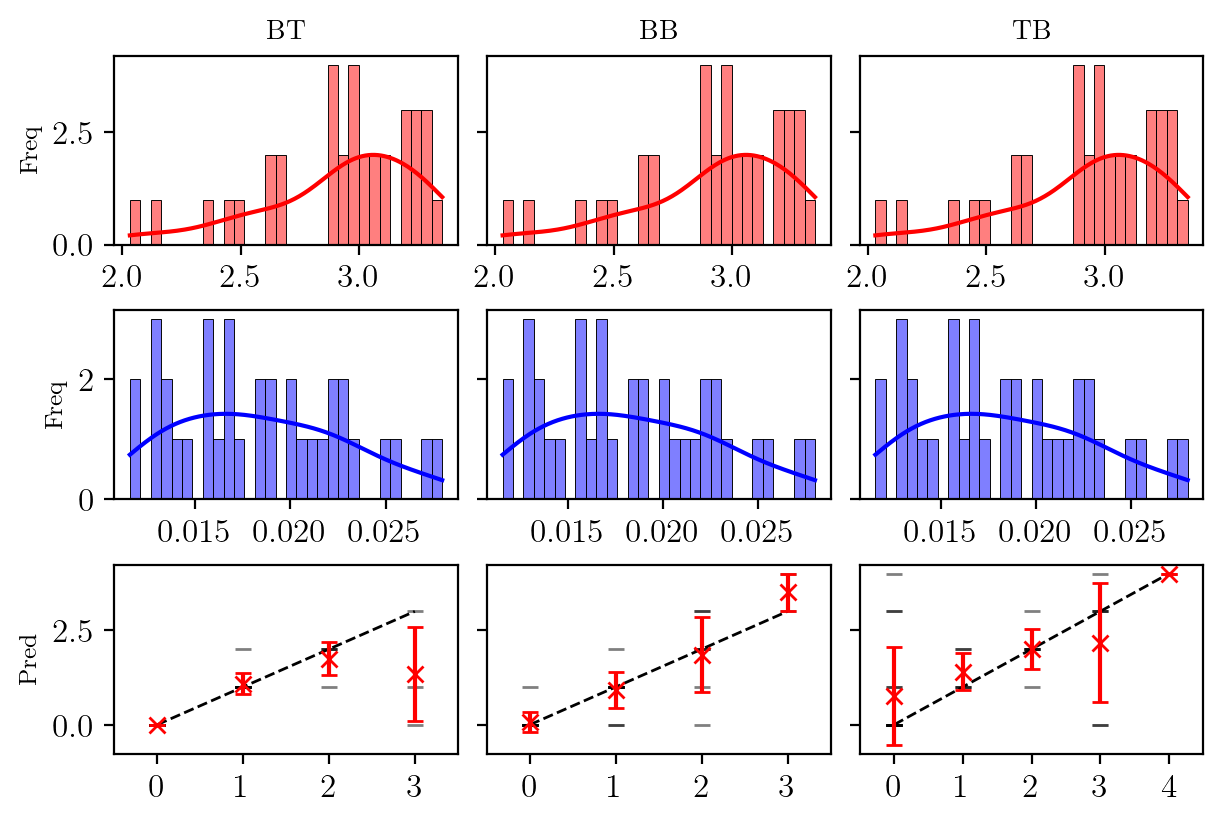

In [11]:
p_conv =  convert_labels(l_p, class_to_poles)*1.0
l_conv =  convert_labels(l, class_to_poles)*1.0

plot_uncer(p_conv, l_conv, np.tile(unks["expected_entropy"][:, None], 3), np.tile(unks["mutual_information"][:, None], 3))

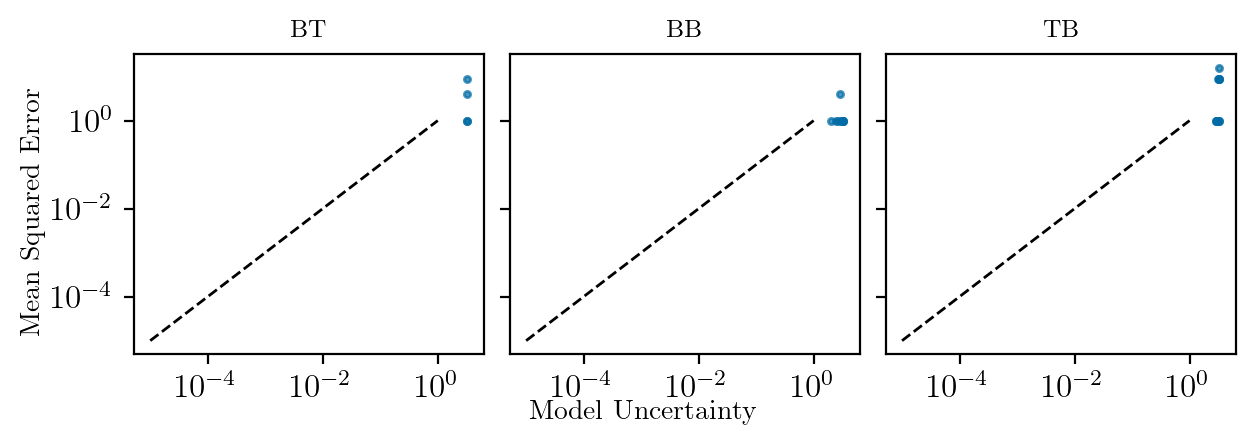

In [12]:
plot_uncer_against_exact(p_conv, l_conv, np.tile(unks["expected_entropy"][:, None], 3))

(array([1., 0., 0., 1., 1., 0., 1., 3., 2., 7.]),
 array([2.03111363, 2.15559986, 2.28008609, 2.40457232, 2.52905856,
        2.65354479, 2.77803102, 2.90251725, 3.02700348, 3.15148972,
        3.27597595]),
 <BarContainer object of 10 artists>)

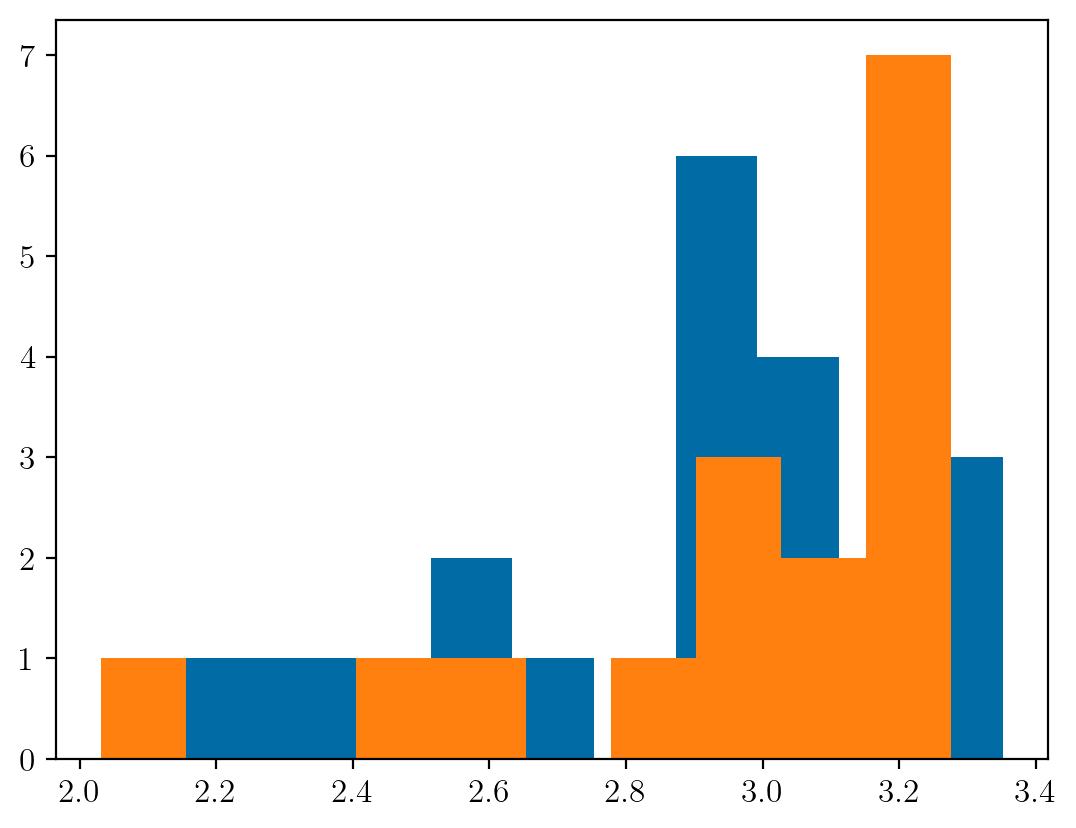

In [28]:
true_inx = np.sum(p_conv == l_conv,axis=1) == 3
false_inx = np.sum(p_conv == l_conv,axis=1) != 3

plt.hist(unks["expected_entropy"][:, None].flatten()[true_inx])
plt.hist(unks["expected_entropy"][:, None].flatten()[false_inx])

In [1]:
# # Train Pool for CatBoost (multi-output regression requires separate models per target)
# models = []
# preds = []
# data_uncertainty = []
# knowledge_uncertainty = []

# for i in range(y_train.shape[1]):
#     train_pool = Pool(X_train, y_train[:, i])
#     val_pool = Pool(X_test, y_test[:, i])


#     model = CatBoostRegressor(
#     iterations=5000,             
#     loss_function='RMSEWithUncertainty',
#     random_seed=0,
#     verbose=100,
#     early_stopping_rounds=10    # Stop early if no improvement
#         )
#     model.fit(train_pool, eval_set=val_pool, use_best_model=False)
#     models.append(model)

#     # Generate predictions with uncertainty
#     pred = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     preds.append(pred[:, 0])  # Mean predictions
#     data_uncertainty.append(pred[:, 2])  # Data uncertainty
#     knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty

# # Convert lists to arrays for easier manipulation
# preds = np.column_stack(preds)
# data_uncertainty = np.column_stack(data_uncertainty)
# knowledge_uncertainty = np.column_stack(knowledge_uncertainty)

In [ ]:
# search_hyp = False
# if search_hyp:

#     # Train Pool for CatBoost (multi-output regression requires separate models per target)
#     models = []
#     preds = []
#     data_uncertainty = []
#     knowledge_uncertainty = []

#     param_grid = {
#         'iterations': [500, 1000, 1500],
#         'learning_rate': [0.01, 0.1, 0.2],
#         'depth': [6, 8, 10],
#         'subsample': [0.5, 0.7, 1.0],
#         'bootstrap_type': ['Bernoulli']
#     }

#     # cv = KFold(n_splits=5, shuffle=True, random_state=0)


#     for i in range(y_train.shape[1]):
#         train_pool = Pool(X_train, y_train[:, i])
#         val_pool = Pool(X_test, y_test[:, i])

#         model = CatBoostRegressor(
#             loss_function='RMSEWithUncertainty',
#             random_seed=0,
#             verbose=100
#             )
        
#         cv_results = model.grid_search(param_grid,
#                     X=train_pool,
#                     cv=2,
#                     partition_random_seed=0,
#                     calc_cv_statistics=True,
#                     search_by_train_test_split=True,
#                     refit=True,
#                     shuffle=True,
#                     stratified=None,
#                     train_size=0.8,
#                     verbose=True,
#                     plot=True)

#         # Generate predictions with uncertainty
#         pred = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#         preds.append(pred[:, 0])  # Mean predictions
#         data_uncertainty.append(pred[:, 2])  # Data uncertainty
#         knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty
         

#     # Convert lists to arrays for easier manipulation
#     preds = np.column_stack(preds)
#     data_uncertainty = np.column_stack(data_uncertainty)
#     knowledge_uncertainty = np.column_stack(knowledge_uncertainty)

In [2]:
# plot_uncer(preds, y_test, data_uncertainty, knowledge_uncertainty)

# Uncer vs MSE

In [3]:
# plot_uncer_against_exact(preds, y_test, data_uncertainty)

# Acc

In [ ]:
predictions_converted = reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
mean_predictions = np.round(np.array(predictions_converted))
accuracy_score(reconvert_labels(y_test, class_to_poles),mean_predictions)
# plot_cm(reconvert_labels(y_test, class_to_poles), mean_predictions, class_to_poles)

In [ ]:
confidence_multiplier = 1.96 # Assuming a certain confidence level, adjust as necessary
for i in range(3):
    lower_bound = (preds[:,i] - confidence_multiplier * np.sqrt(data_uncertainty[:,i]))
    upper_bound = (preds[:,i] + confidence_multiplier * np.sqrt(data_uncertainty[:,i]))

    # Coverage calculation
    covered = np.sum((y_test[:,i] >= lower_bound) & (y_test[:,i] <= upper_bound))
    coverage = covered / len(y_test)
    print("Coverage:", coverage)

In [ ]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
X_exp = np.load("features_exp.npy")
preds_exp = []
data_uncertainty_exp = []
knowledge_uncertainty_exp = []
lower_bound_arr = []
upper_bound_arr = []

for i in range(y_train.shape[1]):
    
    # Generate predictions with uncertainty
    pred = models[i].virtual_ensembles_predict(X_exp, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_exp.append(pred[:, 0])  # Mean predictions
    data_uncertainty_exp.append(pred[:, 2])  # Data uncertainty
    knowledge_uncertainty_exp.append(pred[:, 1])  # Knowledge uncertainty

    lower_bound_arr.append( (pred[:,0] - confidence_multiplier * np.sqrt(pred[:,2])))
    upper_bound_arr.append( (pred[:,0] + confidence_multiplier * np.sqrt(pred[:,2])))

# Convert lists to arrays for easier manipulation
preds_exp = np.column_stack(preds_exp)
data_uncertainty_exp = np.column_stack(data_uncertainty_exp)
knowledge_uncertainty_exp = np.column_stack(knowledge_uncertainty_exp)
lower_bound_arr = np.column_stack(lower_bound_arr)
upper_bound_arr = np.column_stack(upper_bound_arr)

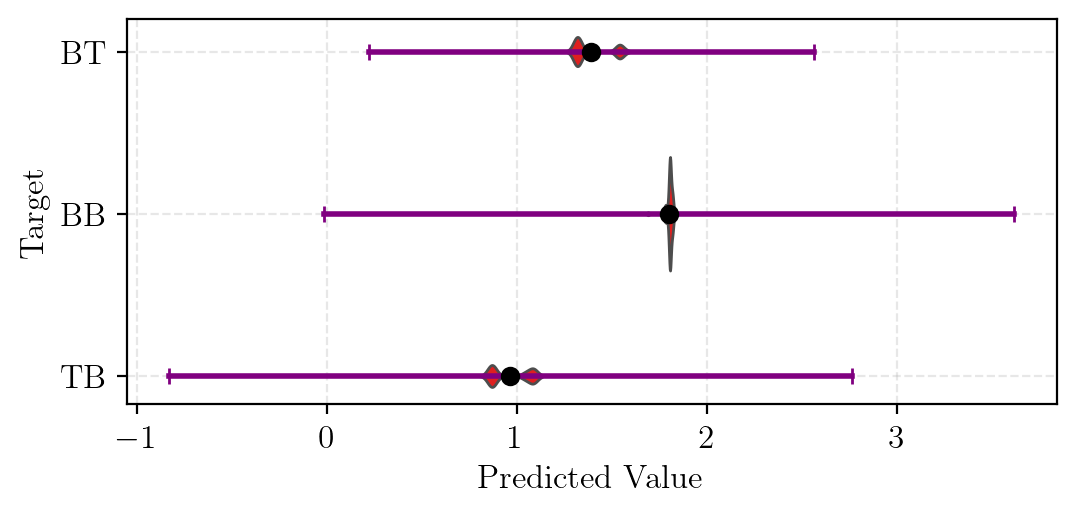

In [ ]:
targets = ["BT", "BB", "TB"]

# Convert to DataFrame
df = pd.DataFrame({
    "Target": np.tile(targets, preds_exp.shape[0] ),
    "Predicted": preds_exp.flatten(),
    "Lower Bound": lower_bound_arr.flatten(),
    "Upper Bound": upper_bound_arr.flatten(),
})

plot_predictions_with_confidence(df)

In [ ]:


# rounded_preds = np.round(preds_exp).astype(int)

# # Ensure values stay within [0, 2]
# rounded_preds = np.clip(rounded_preds, 0, 2)

# # Compute probabilities for each class
# likelihoods = pd.DataFrame(rounded_preds).apply(lambda x: x.value_counts(normalize=True)).fillna(0)

# # Rename columns for clarity
# likelihoods.columns = ["bt", "bb", "tb"]
# likelihoods.index.name = "Class"

# # Display likelihoods
# print(likelihoods)

In [ ]:
likelihoods

NameError: name 'likelihoods' is not defined

In [ ]:

# Define class boundaries
class_boundaries = np.array([0.5, 1.5, 2.5, 3.5])  # Boundaries between classes 0-1 and 1-2

# Compute likelihoods for each position (bt, bb, tb)
likelihoods = {
    "bt": compute_class_probabilities(lower_bound_arr[:,0], upper_bound_arr[:, 0], class_boundaries),
    "bb": compute_class_probabilities(lower_bound_arr[:,1], upper_bound_arr[:, 1], class_boundaries),
    "tb": compute_class_probabilities(lower_bound_arr[:,2], upper_bound_arr[:, 2], class_boundaries)
}

# Convert to DataFrame
likelihoods_df = pd.DataFrame(likelihoods, index=["Class 0", "Class 1", "Class 2"])

# Display likelihoods
print(likelihoods_df)


ValueError: Length of values (5) does not match length of index (3)

In [ ]:
stop

NameError: name 'stop' is not defined

# Training Threshold

In [ ]:
preds_train = []
data_uncertainty_train = []
knowledge_uncertainty_train = []

preds_test = []
data_uncertainty_test = []
knowledge_uncertainty_test = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train, y_train[:, i])
    val_pool = Pool(X_test, y_test[:, i])

    model = models[i]

    # Generate predictions with uncertainty
    pred_train = model.virtual_ensembles_predict(X_train, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_train.append(pred_train[:, 0])  # Mean predictions
    data_uncertainty_train.append(pred_train[:, 2])  # Data uncertainty
    knowledge_uncertainty_train.append(pred_train[:, 1])  # Knowledge uncertainty

    pred_test = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_test.append(pred_test[:, 0])  # Mean predictions
    data_uncertainty_test.append(pred_test[:, 2])  # Data uncertainty
    knowledge_uncertainty_test.append(pred_test[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds_train = np.column_stack(preds_train)
data_uncertainty_train = np.column_stack(data_uncertainty_train)
knowledge_uncertainty_train = np.column_stack(knowledge_uncertainty_train)

preds_test = np.column_stack(preds_test)
data_uncertainty_test = np.column_stack(data_uncertainty_test)
knowledge_uncertainty_test = np.column_stack(knowledge_uncertainty_test)

In [ ]:
optimized_thresholds = optimize_thresholds(preds_train, y_train, class_to_poles)
print("Optimized Thresholds:", optimized_thresholds)

Optimization result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.8729629629629629
             x: [ 4.899e-01  4.893e-01  4.749e-01  5.188e-01  4.951e-01
                  5.284e-01  4.582e-01  5.924e-01]
           nit: 70
          nfev: 186
 final_simplex: (array([[ 4.899e-01,  4.893e-01, ...,  4.582e-01,
                         5.924e-01],
                       [ 4.899e-01,  4.893e-01, ...,  4.582e-01,
                         5.924e-01],
                       ...,
                       [ 4.899e-01,  4.893e-01, ...,  4.582e-01,
                         5.924e-01],
                       [ 4.899e-01,  4.893e-01, ...,  4.582e-01,
                         5.924e-01]]), array([-8.730e-01, -8.730e-01, -8.730e-01, -8.730e-01,
                       -8.730e-01, -8.730e-01, -8.730e-01, -8.730e-01,
                       -8.730e-01]))
Optimized Thresholds: [0.48985647 0.48926699 0.47491496 0.51878173 0.49506742 0.528423

In [ ]:
adjusted_preds_train = round_with_thresholds(preds_train, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds_train) == y_train, axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds_train == y_train, axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.8584
Test Accuracy Improved: 0.8730


In [ ]:
adjusted_preds = round_with_thresholds(preds, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds) == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.8258
Test Accuracy: 0.8392


In [ ]:
# Test Accuracy Baselie: 0.9281
# Test Accuracy Improved: 0.9326

# Test Accuracy Baselie: 0.8554
# Test Accuracy Improved: 0.8638

# Removing

/tmp/ipykernel_10244/1589510332.py:22: RuntimeWarning: invalid value encountered in scalar divide
  acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]


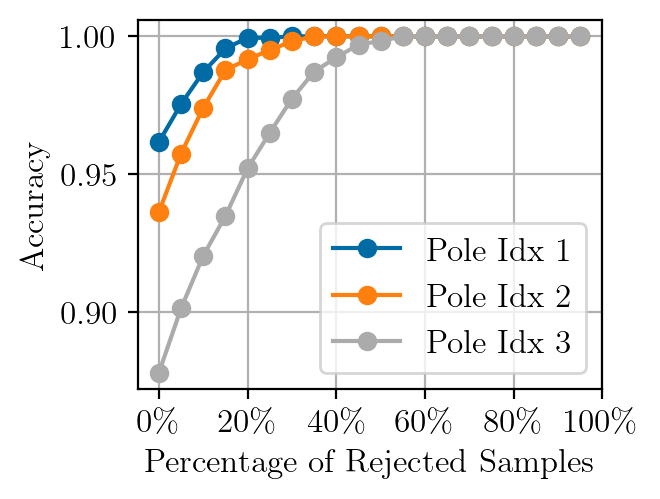

In [ ]:
# Sort the data by uncertainty for each target
mse_changes = []
percent_removed = []

for i in range(y_train.shape[1]):
    sorted_indices = np.argsort(data_uncertainty[:, i])[::-1] 
    sorted_uncertainties = data_uncertainty[sorted_indices, i]
    sorted_true = y_test[sorted_indices, i]
    sorted_preds = preds[sorted_indices, i]

    # Calculate the MSE after removing samples with the highest uncertainty
    acc_list = []
    percent_list = []
    total_samples = len(sorted_uncertainties)

    for remove_percent in range(0, 101, 5):  # Remove in 5% increments
        num_remove = int(total_samples * (remove_percent / 100))
        remaining_true = sorted_true[num_remove:]
        remaining_preds = sorted_preds[num_remove:]

        # mse = np.mean((remaining_true - remaining_preds) ** 2)  # Calculate MSE
        acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]
        acc_list.append(acc)
        percent_list.append(remove_percent)
        

    mse_changes.append(acc_list)
    percent_removed.append(percent_list)

# Plot the results
# plt.figure(figsize=(15, 5))
fig, axs = plt.subplots(1,figsize=(3.54331, 3.54331*0.75))

for i in range(y_train.shape[1]):
    axs.plot(percent_removed[i], mse_changes[i],"-o", label=f"Pole Idx {i+1}")
axs.set_xlabel("Percentage of Rejected Samples")
axs.set_ylabel("Accuracy")
# axs.set_title("Impact of Removing High-Uncertainty Samples on Acc")
axs.legend()
axs.set_xticks([0, 20, 40, 60, 80, 100])
axs.set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
axs.grid(True)
fig.tight_layout()
# fig.show()

# Hist

In [ ]:
# # Number of classes
# num_classes = 8
# custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]
# # Initialize an array to store accuracies for each class across folds
# class_accuracies= []
# class_uncer = []


# for cls in range(num_classes):
#     # Mask for the current class
    
#     class_mask = (reconvert_labels(y_test, class_to_poles) == cls)
#     # Calculate accuracy for the current fold and class
#     # /np.sum(np.ones_like(y_test[:,0]))
#     class_accuracy = np.sum(np.sum(adjusted_preds[class_mask]==y_test[class_mask],axis=1) == 3) / np.sum(class_mask)
#     class_accuracies.append(class_accuracy)

#     class_u = np.mean(data_uncertainty_test[class_mask])
#     class_uncer.append(class_u)

# class_accuracies = np.array(class_accuracies)
# class_uncer = np.array(class_uncer)
# # Bar plot with error bars
# sorted_indices = np.argsort(class_accuracies)[::-1]
# sorted_means = class_accuracies[sorted_indices]
# sorted_stds = class_uncer[sorted_indices]
# sorted_labels = [str(class_to_poles[i]) for i in sorted_indices]

# # Plotting
# fig, ax = plt.subplots(figsize=(3.54331, 3.54331*0.75))
# ax.bar(range(num_classes), sorted_means, yerr=sorted_stds, capsize=5)
# ax.set_ylabel('Accuracy')

# ax.set_xticks(np.arange(len(sorted_labels)))
# ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=10)
# ax.set_ylim(0,1)
# # Adjust layout and show the plot
# plt.tight_layout()
# plt.show()

In [ ]:
# custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# # Compute the confusion matrix
# predictions = reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
# cm = confusion_matrix(reconvert_labels(y_test, class_to_poles), predictions, labels=np.arange(len(class_to_poles)))

# # Plot the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
# fig, ax = plt.subplots(figsize=(5, 5))  # Adjust figure size if needed
# disp.plot(ax=ax)

# # Update x and y axis tick labels with the custom labels
# ax.set_xticks(np.arange(len(custom_labels)))
# ax.set_yticks(np.arange(len(custom_labels)))
# ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
# ax.set_yticklabels(custom_labels, fontsize=10)

# # Adjust layout for readability
# plt.tight_layout()
# plt.show()

# Anomaly detection

In [ ]:
# ext_old_label_arr = np.array([np.tile(i,np.load(f"{'dataExt/P'}{0:02d}{'_intensity.pkl'}", allow_pickle=True).shape[0]) for i in np.arange(35)]).flatten()
# ext_class_to_poles = {
#     0: [0, 0, 0],  # 1 pole on [bt]
#     1: [1, 0, 0],  # 1 pole on [bb]
#     2: [0, 1, 0],  # 1 pole on [tb]
#     3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
#     4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
#     5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
#     6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
#     7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
#     8: [1, 0, 1],
#     9: [0, 1, 1],
#     10: [3, 0, 0],
#     11: [0, 3, 0],
#     12: [0, 0, 3],
#     13: [2, 1, 0],
#     14: [2, 0, 1],
#     15: [1, 2, 0],
#     16: [0, 2, 1],
#     17: [1, 0, 2],
#     18: [0, 1, 2],
#     19: [1, 1, 1],
#     20: [4, 0, 0],
#     21: [0, 4, 0],
#     22: [0, 0, 4],
#     23: [3, 1, 0],
#     24: [3, 0, 1],
#     25: [1, 3, 0],
#     26: [0, 3, 1],
#     27: [1, 0, 3],
#     28: [0, 1, 3],
#     29: [2, 2, 0],
#     30: [2, 0, 2],
#     31: [0, 2, 2],
#     32: [2, 1, 1],
#     33: [1, 2, 1],
#     34: [1, 1, 2],
# }



# ext_label_arr = convert_labels(ext_old_label_arr, ext_class_to_poles)
# ext_features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')

In [ ]:
# ext_X_outside = ext_features_memmap[np.where((ext_label_arr == [2,0,0]).all(axis=1))[0]]
# ext_y_outside = ext_label_arr[np.where((ext_label_arr == [2,0,0]).all(axis=1))[0]]

# ext_X_inside = features_memmap[np.where((new_label_arr == [1,0,0]).all(axis=1))[0]]
# ext_y_inside = new_label_arr[np.where((new_label_arr == [1,0,0]).all(axis=1))[0]]

In [ ]:
# extented_preds_outside = []
# extented_data_uncertainty_outside = []
# extented_knowledge_uncertainty_outside = []

# extented_preds_inside = []
# extented_data_uncertainty_inside = []
# extented_knowledge_uncertainty_inside = []

# for i in range(y_train.shape[1]):
    
#     model = models[i]

#     # Generate predictions with uncertainty
#     pred_outside = model.virtual_ensembles_predict(ext_X_outside, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     extented_preds_outside.append(pred_outside[:, 0])  # Mean predictions
#     extented_data_uncertainty_outside.append(pred_outside[:, 2])  # Data uncertainty
#     extented_knowledge_uncertainty_outside.append(pred_outside[:, 1])  # Knowledge uncertainty

#         # Generate predictions with uncertainty
#     pred_inside = model.virtual_ensembles_predict(ext_X_inside, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     extented_preds_inside.append(pred_inside[:, 0])  # Mean predictions
#     extented_data_uncertainty_inside.append(pred_inside[:, 2])  # Data uncertainty
#     extented_knowledge_uncertainty_inside.append(pred_inside[:, 1])  # Knowledge uncertainty

# # Convert lists to arrays for easier manipulation
# extented_preds_outside = np.column_stack(extented_preds_outside)
# extented_data_uncertainty_outside = np.column_stack(extented_data_uncertainty_outside)
# extented_knowledge_uncertainty_outside = np.column_stack(extented_knowledge_uncertainty_outside)

# # Convert lists to arrays for easier manipulation
# extented_preds_inside = np.column_stack(extented_preds_inside)
# extented_data_uncertainty_inside = np.column_stack(extented_data_uncertainty_inside)
# extented_knowledge_uncertainty_inside = np.column_stack(extented_knowledge_uncertainty_inside)

In [ ]:
# # Define a shared bin range
# bins = np.linspace(
#     min(extented_data_uncertainty_outside.min(), extented_data_uncertainty_inside.min(),
#         extented_knowledge_uncertainty_outside.min(), extented_knowledge_uncertainty_inside.min()),
#     max(extented_data_uncertainty_outside.max(), extented_data_uncertainty_inside.max(),
#         extented_knowledge_uncertainty_outside.max(), extented_knowledge_uncertainty_inside.max()),
#     50
# )

# # Plot Data Uncertainty
# plt.figure(figsize=(15/2, 5/2))
# for i in range(y_train.shape[1]):
#     plt.subplot(1, 3, i + 1)
#     sns.histplot(extented_data_uncertainty_outside[:, i], kde=False, bins=bins, color='red', label="Outside", alpha=0.6)
#     sns.histplot(extented_data_uncertainty_inside[:, i], kde=False, bins=bins, color='blue', label="Inside", alpha=0.6)
#     plt.title(f"Data Uncertainty for Target {i+1}")
#     plt.xlabel("Uncertainty")
#     plt.ylabel("Frequency")
#     # if i == 0:  # Add legend to the first subplot only
#     #     plt.legend(title="Source")
# plt.tight_layout()
# plt.show()

# # Plot Knowledge Uncertainty
# plt.figure(figsize=(15/2, 5/2))
# for i in range(y_train.shape[1]):
#     plt.subplot(1, 3, i + 1)
#     sns.histplot(extented_knowledge_uncertainty_outside[:, i], kde=False, bins=bins, color='red', label="Outside", alpha=0.6)
#     sns.histplot(extented_knowledge_uncertainty_inside[:, i], kde=False, bins=bins, color='blue', label="Inside", alpha=0.6)
#     plt.title(f"Knowledge Uncertainty for Target {i+1}")
#     plt.xlabel("Uncertainty")
#     plt.ylabel("Frequency")
#     if i == 0:  # Add legend to the first subplot only
#         plt.legend(title="Source")
# plt.tight_layout()
# plt.show()
